# Art Image Classification
Classify art images into 5 categories: drawings, engraving, iconography, painting, sculpture.

Dataset: Art Images (Kaggle) - https://www.kaggle.com/datasets/thedownhill/art-images-drawings-painting-sculpture-engraving

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import load_img
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pickle

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
TRAIN_DIR = 'dataset/training_set'
VAL_DIR = 'dataset/validation_set'
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
CLASS_NAMES = ['drawings', 'engraving', 'iconography', 'painting', 'sculpture']

# Create folders for outputs
os.makedirs('model', exist_ok=True)
os.makedirs('static/plots', exist_ok=True)

In [3]:
# Dataset cleanup: remove non-image and corrupted files
# (Kaggle archives often contain .DS_Store, Thumbs.db, truncated JPEGs)
from PIL import Image

VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
removed = []

for split_dir in [TRAIN_DIR, VAL_DIR]:
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            fpath = os.path.join(cls_dir, fname)
            ext = os.path.splitext(fname)[1].lower()

            # Remove anything that isn't a known image extension
            if ext not in VALID_EXT:
                os.remove(fpath)
                removed.append(fpath)
                continue

            # Verify the image actually opens
            try:
                with Image.open(fpath) as im:
                    im.verify()
            except Exception:
                os.remove(fpath)
                removed.append(fpath)

print(f"Removed {len(removed)} bad files")
for f in removed[:10]:
    print(" -", f)
if len(removed) > 10:
    print(f" ... and {len(removed) - 10} more")

Removed 0 bad files


## explore data

In [4]:
# Count images per class
train_counts = {}
val_counts = {}
for cls in CLASS_NAMES:
    train_counts[cls] = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    val_counts[cls] = len(os.listdir(os.path.join(VAL_DIR, cls)))

counts_df = pd.DataFrame({'Train': train_counts, 'Validation': val_counts})
print(counts_df)
print()
print("Total train:", counts_df['Train'].sum())
print("Total val:", counts_df['Validation'].sum())

             Train  Validation
drawings      1107         122
engraving      757          84
iconography   2077         231
painting      2042         228
sculpture     1738         191

Total train: 7721
Total val: 856


## visualization

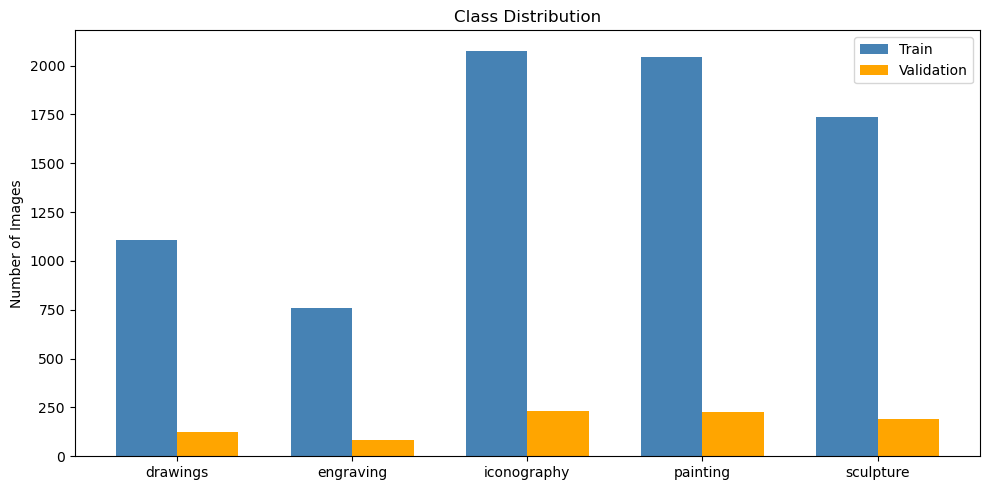

In [5]:
# Class distribution bar chart
x = np.arange(len(CLASS_NAMES))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, counts_df['Train'], width, label='Train', color='steelblue')
plt.bar(x + width/2, counts_df['Validation'], width, label='Validation', color='orange')
plt.xticks(x, CLASS_NAMES)
plt.ylabel('Number of Images')
plt.title('Class Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('static/plots/class_distribution.png', dpi=150)
plt.show()

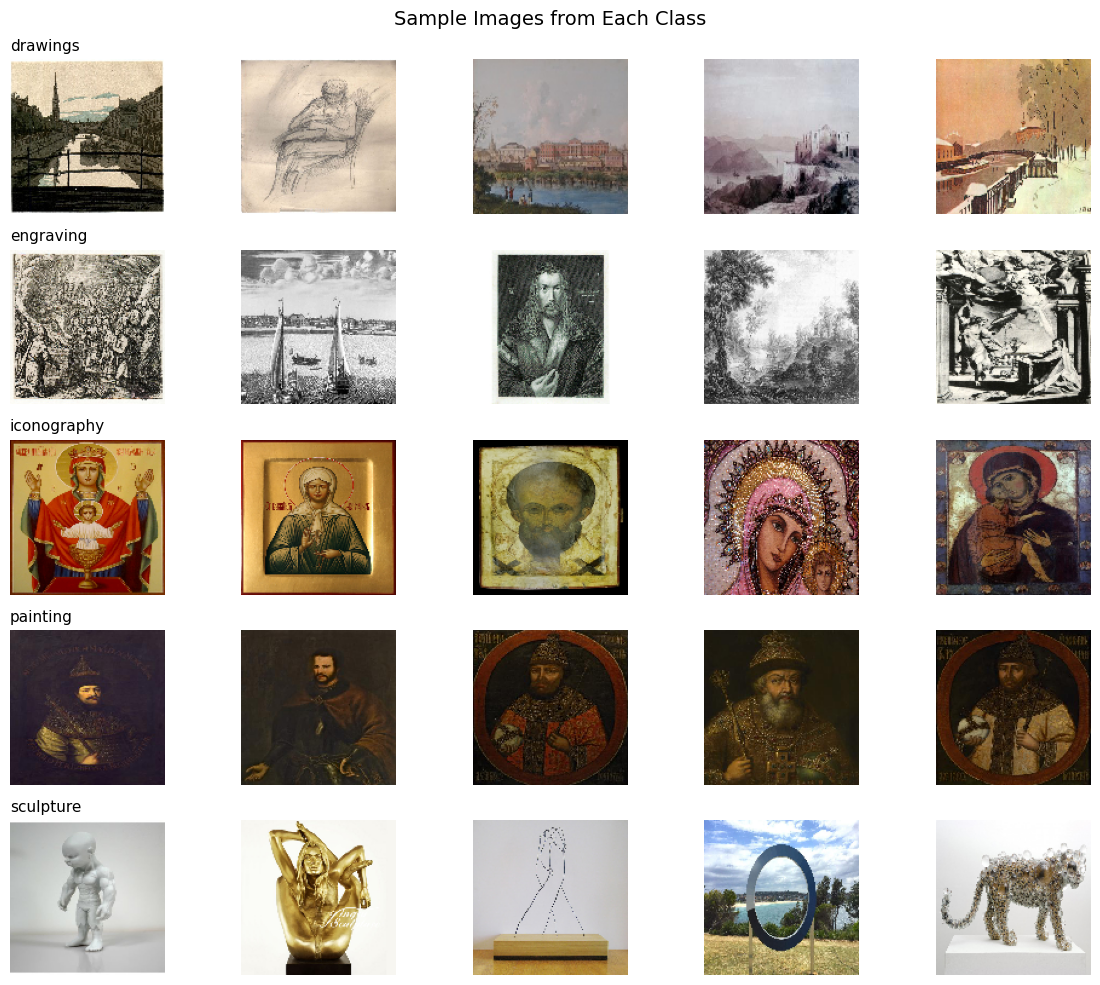

In [6]:
# Sample images grid (5 per class)
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}

plt.figure(figsize=(12, 10))
for i, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    # Only show valid image files, skip any that fail to load
    files = [f for f in sorted(os.listdir(cls_dir))
             if os.path.splitext(f)[1].lower() in VALID_EXT][:5]
    for j, f in enumerate(files):
        try:
            img = load_img(os.path.join(cls_dir, f), target_size=IMG_SIZE)
        except Exception:
            continue
        plt.subplot(5, 5, i*5 + j + 1)
        plt.imshow(img)
        plt.axis('off')
        if j == 0:
            plt.title(cls, loc='left', fontsize=11)
plt.suptitle('Sample Images from Each Class', fontsize=14)
plt.tight_layout()
plt.savefig('static/plots/sample_grid.png', dpi=150)
plt.show()

## preprocessing

In [7]:
# Training data with augmentation (rotation, flip, zoom - from lecture slide 5)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

# Validation data: just rescale, no augmentation
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 7721 images belonging to 5 classes.
Found 856 images belonging to 5 classes.
Class indices: {'drawings': 0, 'engraving': 1, 'iconography': 2, 'painting': 3, 'sculpture': 4}


## simple CNN

In [8]:
# Simple CNN - 2 conv blocks + 1 dense layer
simple_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(5, activation='softmax')
])

simple_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

simple_cnn.summary()

c:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,965 (28.20 MB)

 Trainable params: 7,392,965 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
simple_history = simple_cnn.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

Epoch 1/10
134/242 ━━━━━━━━━━━━━━━━━━━━ 51s 476ms/step - accuracy: 0.4686 - loss: 1.6625

c:\Users\User\anaconda3\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


242/242 ━━━━━━━━━━━━━━━━━━━━ 126s 505ms/step - accuracy: 0.6701 - loss: 0.9259 - val_accuracy: 0.7418 - val_loss: 0.7187
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 111s 461ms/step - accuracy: 0.7765 - loss: 0.6127 - val_accuracy: 0.7874 - val_loss: 0.5623
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 83s 341ms/step - accuracy: 0.8027 - loss: 0.5384 - val_accuracy: 0.7979 - val_loss: 0.5602
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 79s 325ms/step - accuracy: 0.8183 - loss: 0.4924 - val_accuracy: 0.8201 - val_loss: 0.4685
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 81s 333ms/step - accuracy: 0.8299 - loss: 0.4668 - val_accuracy: 0.8084 - val_loss: 0.5218
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 121s 501ms/step - accuracy: 0.8377 - loss: 0.4435 - val_accuracy: 0.8154 - val_loss: 0.5144
Epoch 7/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 93s 382ms/step - accuracy: 0.8517 - loss: 0.4108 - val_accuracy: 0.8283 - val_loss: 0.4672
Epoch 8/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 98s 407ms/step - accuracy: 0.8539 - loss: 0.3874 - 

## deeper CNN with dropout

In [10]:
# Deeper CNN - 3 conv blocks + dropout (from lecture slide 26)
deeper_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

deeper_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,317 (24.86 MB)

 Trainable params: 6,517,317 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
deeper_history = deeper_cnn.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen
)

Epoch 1/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 117s 474ms/step - accuracy: 0.6504 - loss: 0.9263 - val_accuracy: 0.6939 - val_loss: 0.8143
Epoch 2/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 110s 456ms/step - accuracy: 0.7597 - loss: 0.6921 - val_accuracy: 0.7780 - val_loss: 0.6647
Epoch 3/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 120s 493ms/step - accuracy: 0.7776 - loss: 0.6156 - val_accuracy: 0.7582 - val_loss: 0.7241
Epoch 4/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 99s 408ms/step - accuracy: 0.7980 - loss: 0.5670 - val_accuracy: 0.7792 - val_loss: 0.6710
Epoch 5/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 98s 406ms/step - accuracy: 0.8095 - loss: 0.5221 - val_accuracy: 0.8049 - val_loss: 0.5623
Epoch 6/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 96s 397ms/step - accuracy: 0.8205 - loss: 0.4914 - val_accuracy: 0.7874 - val_loss: 0.5631
Epoch 7/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 105s 435ms/step - accuracy: 0.8286 - loss: 0.4757 - val_accuracy: 0.8166 - val_loss: 0.5436
Epoch 8/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 139s 574ms/step - accuracy: 0.8324 - lo

## model comparison

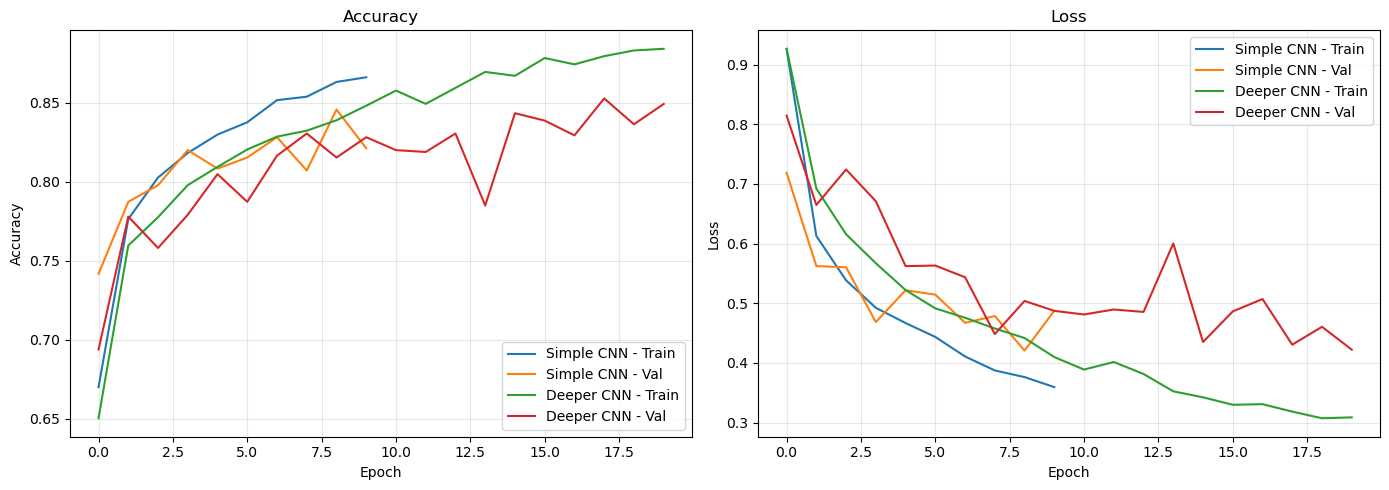

In [12]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(simple_history.history['accuracy'], label='Simple CNN - Train')
axes[0].plot(simple_history.history['val_accuracy'], label='Simple CNN - Val')
axes[0].plot(deeper_history.history['accuracy'], label='Deeper CNN - Train')
axes[0].plot(deeper_history.history['val_accuracy'], label='Deeper CNN - Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(simple_history.history['loss'], label='Simple CNN - Train')
axes[1].plot(simple_history.history['val_loss'], label='Simple CNN - Val')
axes[1].plot(deeper_history.history['loss'], label='Deeper CNN - Train')
axes[1].plot(deeper_history.history['val_loss'], label='Deeper CNN - Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('static/plots/training_curves.png', dpi=150)
plt.show()

In [13]:
# Predictions on validation set
val_gen.reset()
simple_preds = simple_cnn.predict(val_gen, verbose=0)
simple_pred_labels = np.argmax(simple_preds, axis=1)

val_gen.reset()
deeper_preds = deeper_cnn.predict(val_gen, verbose=0)
deeper_pred_labels = np.argmax(deeper_preds, axis=1)

y_true = val_gen.classes

# Metrics
simple_acc = accuracy_score(y_true, simple_pred_labels)
simple_f1 = f1_score(y_true, simple_pred_labels, average='weighted')
simple_prec = precision_score(y_true, simple_pred_labels, average='weighted')
simple_rec = recall_score(y_true, simple_pred_labels, average='weighted')

deeper_acc = accuracy_score(y_true, deeper_pred_labels)
deeper_f1 = f1_score(y_true, deeper_pred_labels, average='weighted')
deeper_prec = precision_score(y_true, deeper_pred_labels, average='weighted')
deeper_rec = recall_score(y_true, deeper_pred_labels, average='weighted')

print("Simple CNN Accuracy:", round(simple_acc * 100, 2), "%")
print("Deeper CNN Accuracy:", round(deeper_acc * 100, 2), "%")
print()
print("Simple CNN Classification Report:")
print(classification_report(y_true, simple_pred_labels, target_names=CLASS_NAMES))
print()
print("Deeper CNN Classification Report:")
print(classification_report(y_true, deeper_pred_labels, target_names=CLASS_NAMES))

Simple CNN Accuracy: 82.13 %
Deeper CNN Accuracy: 84.93 %

Simple CNN Classification Report:
              precision    recall  f1-score   support

    drawings       0.66      0.49      0.56       122
   engraving       0.65      0.74      0.69        84
 iconography       0.86      0.96      0.91       231
    painting       0.98      0.81      0.88       228
   sculpture       0.78      0.92      0.84       191

    accuracy                           0.82       856
   macro avg       0.79      0.78      0.78       856
weighted avg       0.83      0.82      0.82       856


Deeper CNN Classification Report:
              precision    recall  f1-score   support

    drawings       0.72      0.40      0.52       122
   engraving       0.61      0.88      0.72        84
 iconography       0.92      0.95      0.93       231
    painting       0.97      0.90      0.93       228
   sculpture       0.83      0.94      0.88       191

    accuracy                           0.85       856
   

In [14]:
# Comparison table
comparison = pd.DataFrame({
    'Simple CNN': [round(simple_acc, 4), round(simple_f1, 4), round(simple_prec, 4), round(simple_rec, 4)],
    'Deeper CNN': [round(deeper_acc, 4), round(deeper_f1, 4), round(deeper_prec, 4), round(deeper_rec, 4)]
}, index=['Accuracy', 'F1 Score', 'Precision', 'Recall'])

print("Model Comparison:")
comparison

Model Comparison:


,Simple CNN,Deeper CNN
Accuracy,0.8213,0.8493
F1 Score,0.8171,0.8416
Precision,0.8252,0.8540
Recall,0.8213,0.8493


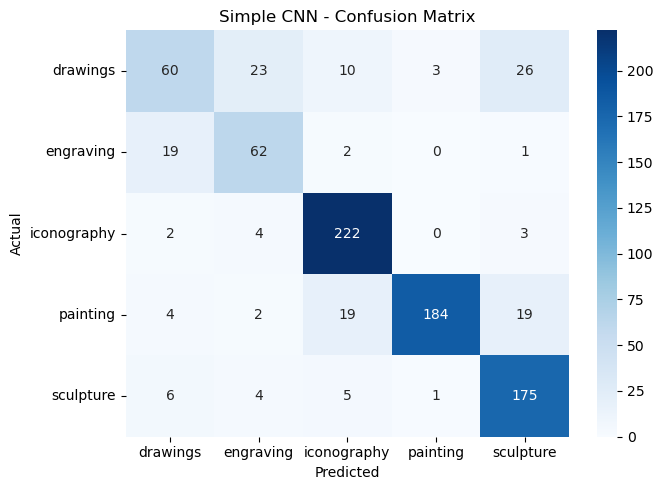

In [15]:
# Confusion Matrix for Simple CNN
cm_simple = confusion_matrix(y_true, simple_pred_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_simple, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Simple CNN - Confusion Matrix')
plt.tight_layout()
plt.savefig('static/plots/confusion_matrix_simple.png', dpi=150)
plt.show()

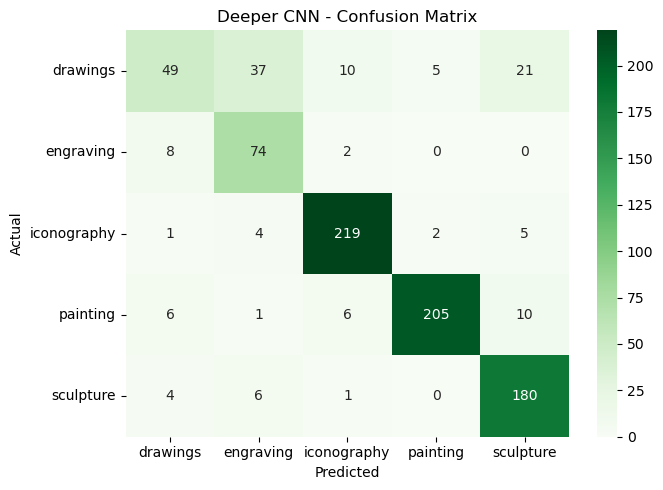

In [16]:
# Confusion Matrix for Deeper CNN
cm_deeper = confusion_matrix(y_true, deeper_pred_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_deeper, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Deeper CNN - Confusion Matrix')
plt.tight_layout()
plt.savefig('static/plots/confusion_matrix_deeper.png', dpi=150)
plt.show()

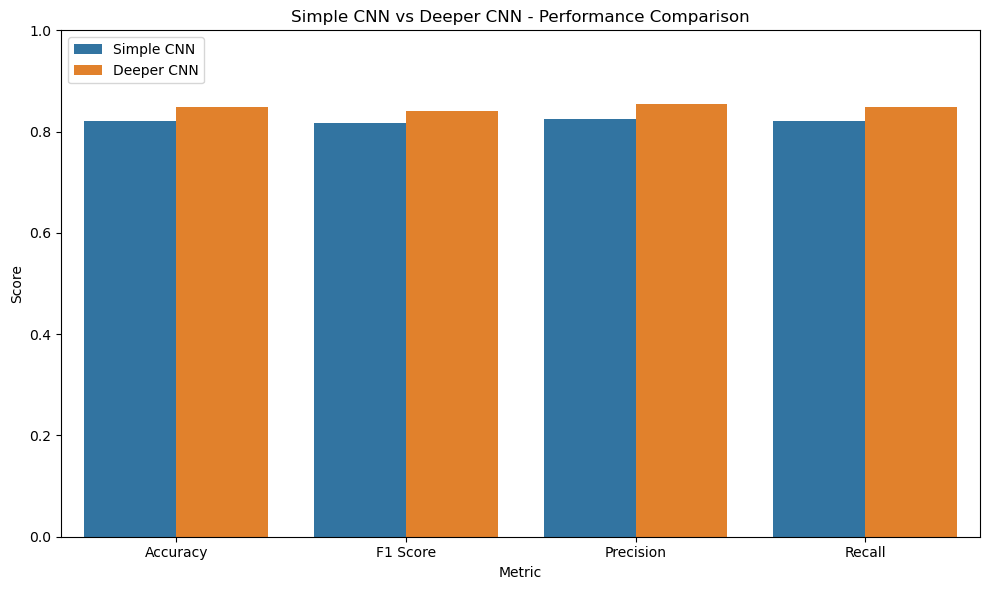

In [17]:
# Model comparison bar chart
metrics_names = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
simple_scores = [simple_acc, simple_f1, simple_prec, simple_rec]
deeper_scores = [deeper_acc, deeper_f1, deeper_prec, deeper_rec]

chart_df = pd.DataFrame({
    'Metric': metrics_names + metrics_names,
    'Score': simple_scores + deeper_scores,
    'Model': ['Simple CNN'] * 4 + ['Deeper CNN'] * 4
})

plt.figure(figsize=(10, 6))
sns.barplot(data=chart_df, x='Metric', y='Score', hue='Model')
plt.title('Simple CNN vs Deeper CNN - Performance Comparison')
plt.ylim(0, 1.0)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('static/plots/model_comparison.png', dpi=150)
plt.show()

## save artifacts

In [18]:
# Pick best model based on F1 score
if deeper_f1 >= simple_f1:
    best_model = deeper_cnn
    best_model_name = 'Deeper CNN'
else:
    best_model = simple_cnn
    best_model_name = 'Simple CNN'

print("Winner:", best_model_name)

# Save the best model
best_model.save('model/classifier.keras')

# Save metadata for Flask app
metadata = {
    'class_names': CLASS_NAMES,
    'img_size': list(IMG_SIZE),
    'best_model': best_model_name,
    'models_metrics': {
        'Simple CNN': {
            'accuracy': round(simple_acc, 4),
            'f1_weighted': round(simple_f1, 4),
            'precision_weighted': round(simple_prec, 4),
            'recall_weighted': round(simple_rec, 4),
        },
        'Deeper CNN': {
            'accuracy': round(deeper_acc, 4),
            'f1_weighted': round(deeper_f1, 4),
            'precision_weighted': round(deeper_prec, 4),
            'recall_weighted': round(deeper_rec, 4),
        }
    }
}

with open('model/metrics.pkl', 'wb') as f:
    pickle.dump(metadata, f)


Winner: Deeper CNN
